In [110]:
#importing importent Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


In [111]:
# installing gdown to load files from Google Drive
!pip install gdown -q
# -q means quiet (dont show installation logs)

import gdown

# Downloading the historical trading data
# (link provided in the task)
gdown.download(
    'https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs',
    'historical_data.csv',
    quiet=True
)

# Downloading the fear greed index data
# (link provided in the task)
gdown.download(
    'https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf',
    'fear_greed_index.csv',
    quiet=True
)

print("Both files downloaded successfully!")

# Now loading them
trades = pd.read_csv('historical_data.csv')
print('Trader data shape:', trades.shape)
print('Columns:', trades.columns.tolist())
trades.head()

Both files downloaded successfully!
Trader data shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [112]:
sentiment = pd.read_csv('fear_greed_index.csv')

print('Sentiment data shape:', sentiment.shape)
print('Date range:', sentiment['date'].min(), 'to', sentiment['date'].max())
sentiment.head()

Sentiment data shape: (2644, 4)
Date range: 2018-02-01 to 2025-05-02


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [113]:
# -- CLEAN AND PREPROCESS --
#converting raw time values such as Unix epoch seconds, milliseconds, or string representations into structured datetime objects
trades['Date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['DateOnly'] = trades['Date'].dt.date
trades['Month'] = trades['Date'].dt.to_period('M')
trades['Hour'] = trades['Date'].dt.hour

print('Date range:', trades['Date'].min().date(), 'to', trades['Date'].max().date())
trades[['Timestamp IST', 'DateOnly', 'Month', 'Hour']].head()

Date range: 2023-05-01 to 2025-05-01


,Timestamp IST,DateOnly,Month,Hour
0,02-12-2024 22:50,2024-12-02,2024-12,22
1,02-12-2024 22:50,2024-12-02,2024-12,22
2,02-12-2024 22:50,2024-12-02,2024-12,22
3,02-12-2024 22:50,2024-12-02,2024-12,22
4,02-12-2024 22:50,2024-12-02,2024-12,22


In [114]:
# net PnL = profit after subtracting fees
trades['Net PnL'] = trades['Closed PnL'] - trades['Fee']

# keeping only closed trades
closed = trades[trades['Closed PnL'] != 0].copy()

print('Total rows:', len(trades))
print('Closed trades:', len(closed))

# label each trade -  1 = profit, 0 = loss
closed['Profitable'] = (closed['Closed PnL'] > 0).astype(int)

print('Win rate:', round(closed['Profitable'].mean() * 100, 1), '%')

Total rows: 211224
Closed trades: 104408
Win rate: 83.2 %


In [115]:
# clean the sentiment dataset
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
sentiment = sentiment.rename(columns={
    'value': 'Sentiment Score',
    'classification': 'Sentiment Label'
})

sentiment[['date', 'Sentiment Score', 'Sentiment Label']].head()

,date,Sentiment Score,Sentiment Label
0,2018-02-01,30,Fear
1,2018-02-02,15,Extreme Fear
2,2018-02-03,40,Fear
3,2018-02-04,24,Extreme Fear
4,2018-02-05,11,Extreme Fear


In [116]:
#Merging the both datasets
closed['DateOnly'] = pd.to_datetime(closed['DateOnly']).dt.date

merged = pd.merge(
    closed,
    sentiment[['date', 'Sentiment Score', 'Sentiment Label']],
    left_on='DateOnly',
    right_on='date',
    how='left'
)

matched = merged['Sentiment Score'].notna().sum()
print(f'Trades matched with sentiment: {matched} / {len(merged)}')

merged[['Coin', 'Side', 'Closed PnL', 'Sentiment Score', 'Sentiment Label']].head(8)

Trades matched with sentiment: 104402 / 104408


,Coin,Side,Closed PnL,Sentiment Score,Sentiment Label
0,@107,SELL,3008.231185,76.0,Extreme Greed
1,@107,SELL,30.741534,76.0,Extreme Greed
2,@107,SELL,40.770089,76.0,Extreme Greed
3,@107,SELL,243.812267,76.0,Extreme Greed
4,@107,SELL,254.263735,76.0,Extreme Greed
5,@107,SELL,24.301227,76.0,Extreme Greed
6,@107,SELL,134.551236,76.0,Extreme Greed
7,@107,SELL,41.230486,76.0,Extreme Greed


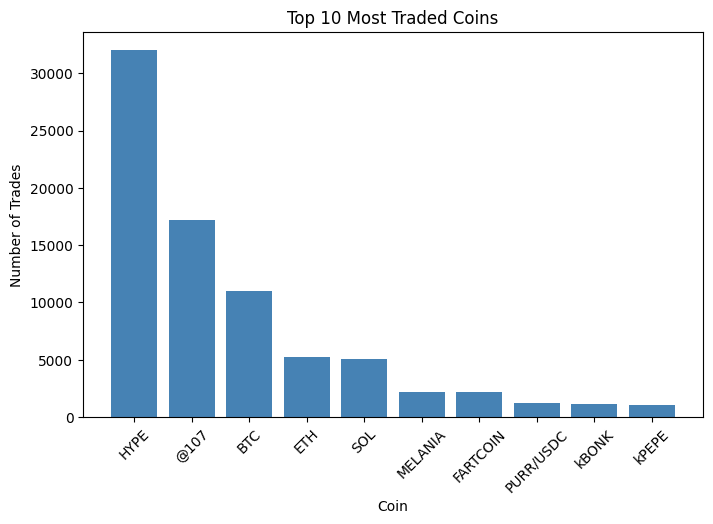

In [117]:
# --EDA--
# top 10 most traded coins
top_coins = merged['Coin'].value_counts().head(10)

plt.figure(figsize=(8, 5))
plt.bar(top_coins.index, top_coins.values, color='steelblue')
plt.title('Top 10 Most Traded Coins')
plt.xlabel('Coin')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.show()

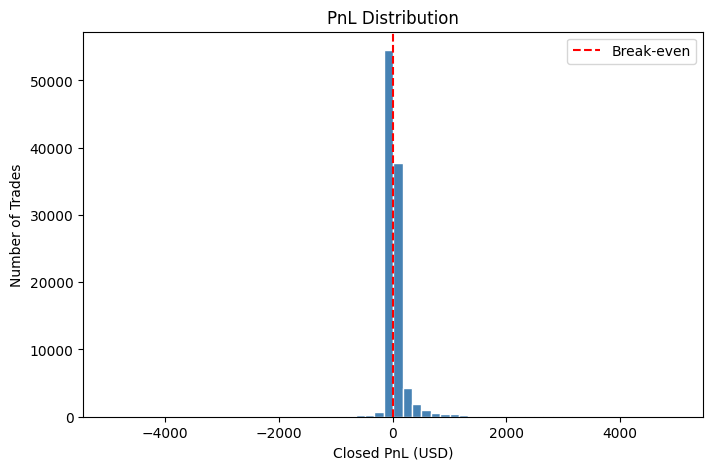

In [118]:
# PnL distribution — filter between -5000 and 5000 so the chart isn't too wide
pnl_filtered = merged[(merged['Closed PnL'] > -5000) & (merged['Closed PnL'] < 5000)]['Closed PnL']

plt.figure(figsize=(8, 5))
plt.hist(pnl_filtered, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='Break-even')
plt.title('PnL Distribution')
plt.xlabel('Closed PnL (USD)')
plt.ylabel('Number of Trades')
plt.legend()
plt.show()

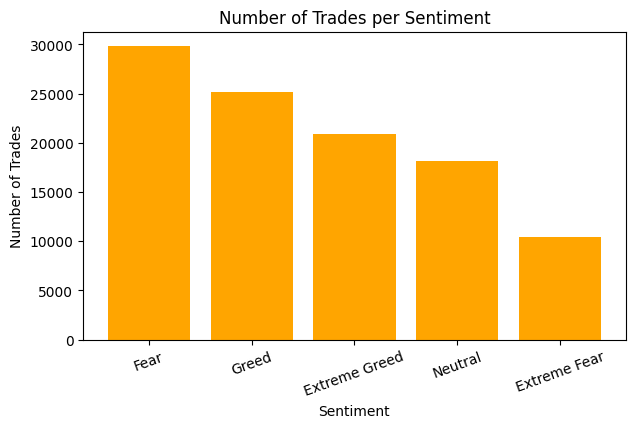

In [119]:
# how many trades happened under each sentiment
sent_counts = merged['Sentiment Label'].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(sent_counts.index, sent_counts.values, color='orange')
plt.title('Number of Trades per Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=20)
plt.show()

In [120]:
# group trades by sentiment and calculate win rate and avg PnL
sentiment_perf = merged.groupby('Sentiment Label').agg(
    Total_Trades=('Profitable', 'count'),
    Win_Rate=('Profitable', 'mean'),
    Avg_PnL=('Closed PnL', 'mean')
).reset_index()

sentiment_perf['Win_Rate'] = (sentiment_perf['Win_Rate'] * 100).round(1)
sentiment_perf['Avg_PnL'] = sentiment_perf['Avg_PnL'].round(2)

print(sentiment_perf)

  Sentiment Label  Total_Trades  Win_Rate  Avg_PnL
0    Extreme Fear         10406      76.2    71.03
1   Extreme Greed         20853      89.2   130.21
2            Fear         29808      87.3   112.63
3           Greed         25176      76.9    85.40
4         Neutral         18159      82.4    71.20


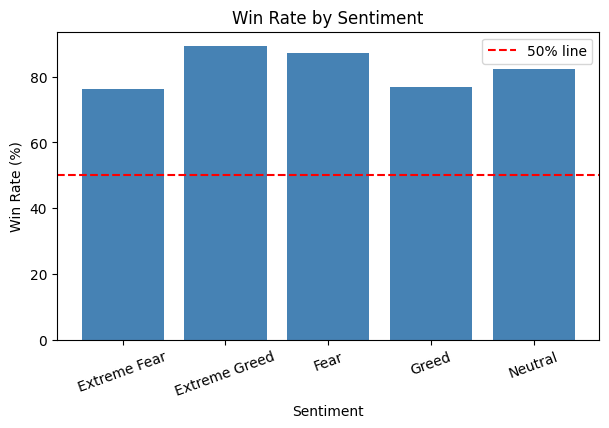

In [121]:
# win rate by sentiment
plt.figure(figsize=(7, 4))
plt.bar(sentiment_perf['Sentiment Label'], sentiment_perf['Win_Rate'], color='steelblue')
plt.axhline(50, color='red', linestyle='--', label='50% line')
plt.title('Win Rate by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=20)
plt.legend()
plt.show()

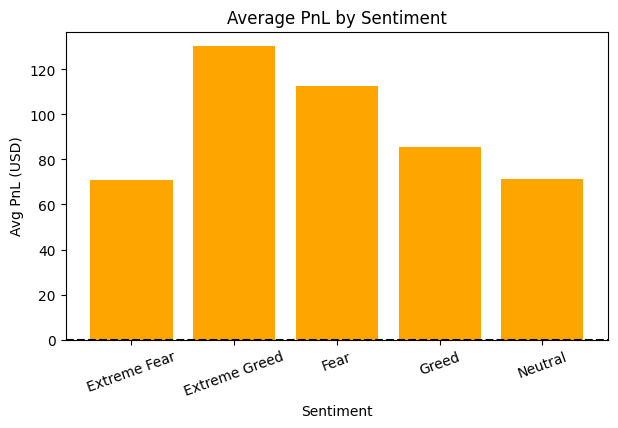

In [122]:
# average PnL by sentiment
plt.figure(figsize=(7, 4))
plt.bar(sentiment_perf['Sentiment Label'], sentiment_perf['Avg_PnL'], color='orange')
plt.axhline(0, color='black', linestyle='--')
plt.title('Average PnL by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg PnL (USD)')
plt.xticks(rotation=20)
plt.show()

In [123]:
#--ML MODELS--
# only keep rows that have sentiment data
ml_data = merged.dropna(subset=['Sentiment Score']).copy()

# ML models only work with numbers, so we convert text columns to numbers
le = LabelEncoder()
ml_data['Side_enc'] = le.fit_transform(ml_data['Side'])
ml_data['Direction_enc'] = le.fit_transform(ml_data['Direction'])
ml_data['Coin_enc'] = le.fit_transform(ml_data['Coin'])
ml_data['Sentiment_enc'] = le.fit_transform(ml_data['Sentiment Label'])

print('Text columns converted to numbers successfully')

Text columns converted to numbers successfully


In [124]:
# define what we feed into the model (features) and what we want to predict (target)
features = ['Size USD', 'Side_enc', 'Direction_enc', 'Coin_enc', 'Fee', 'Sentiment Score', 'Sentiment_enc']

X = ml_data[features]
y = ml_data['Profitable']

# split: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training size:', len(X_train))
print('Testing size:', len(X_test))

Training size: 83521
Testing size: 20881


In [125]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100

print('Model Accuracy:', round(acc, 1), '%')
print()
print(classification_report(y_test, y_pred, target_names=['Loss', 'Profit']))

Model Accuracy: 58.4 %

              precision    recall  f1-score   support

        Loss       0.23      0.60      0.33      3513
      Profit       0.88      0.58      0.70     17368

    accuracy                           0.58     20881
   macro avg       0.55      0.59      0.51     20881
weighted avg       0.77      0.58      0.64     20881



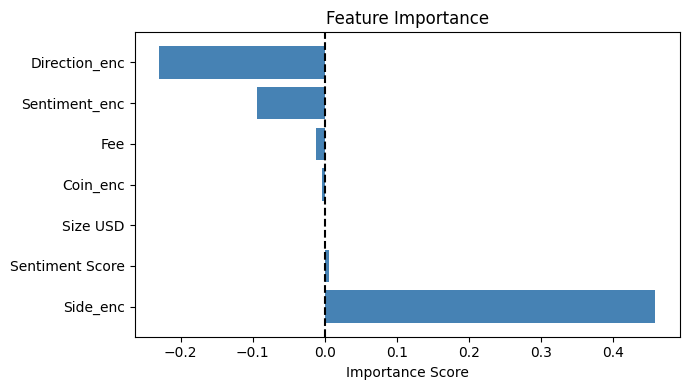

In [126]:
# which features did the model rely on most?
coef_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.coef_[0]
})
coef_df = coef_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(7, 4))
plt.barh(coef_df['Feature'], coef_df['Importance'], color='steelblue')
plt.axvline(0, color='black', linestyle='--')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [127]:
# key insight after using just logestic regression
best_sent = sentiment_perf.sort_values('Avg_PnL', ascending=False).iloc[0]
worst_sent = sentiment_perf.sort_values('Avg_PnL').iloc[0]

print('Total traders:', merged['Account'].nunique())
print('Total closed trades:', len(merged))
print('Overall win rate:', round(merged['Profitable'].mean() * 100, 1), '%')
print('Most traded coin:', merged['Coin'].value_counts().index[0])
print('Best sentiment to trade in:', best_sent['Sentiment Label'], '| Avg PnL: $', best_sent['Avg_PnL'])
print('Worst sentiment to trade in:', worst_sent['Sentiment Label'], '| Avg PnL: $', worst_sent['Avg_PnL'])
print('ML Model Accuracy:', round(acc, 1), '%')

Total traders: 32
Total closed trades: 104408
Overall win rate: 83.2 %
Most traded coin: HYPE
Best sentiment to trade in: Extreme Greed | Avg PnL: $ 130.21
Worst sentiment to trade in: Extreme Fear | Avg PnL: $ 71.03
ML Model Accuracy: 58.4 %


In [128]:
# So far we only used Logistic Regression
# But how do we know it's the best algorithm?
# and compare them to find the best one

# We will test 4 more algorithms:
# 1. Decision Tree
# 2. Random Forest
# 3. Gradient Boosting
# 4. XGBoost


In [129]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

# StandardScaler
from sklearn.preprocessing import StandardScaler

# Another way to measure model quality
from sklearn.metrics import roc_auc_score

print("All new libraries imported successfully!")

All new libraries imported successfully!


In [130]:
ml_data = merged.dropna(subset=['Sentiment Score']).copy()

# Create a SEPARATE encoder for EACH column  this encoder is ONLY for Side column
le_side = LabelEncoder()

# this encoder is ONLY for Direction column
le_direction = LabelEncoder()

# this encoder is ONLY for Coin column
le_coin = LabelEncoder()

# this encoder is ONLY for Sentiment Label column
le_sentiment = LabelEncoder()

# fit_transform = first learn the categories, then convert
ml_data['Side_enc'] = le_side.fit_transform(ml_data['Side'])

ml_data['Direction_enc'] = le_direction.fit_transform(
    ml_data['Direction']
)

ml_data['Coin_enc'] = le_coin.fit_transform(ml_data['Coin'])


ml_data['Sentiment_enc'] = le_sentiment.fit_transform(
    ml_data['Sentiment Label']
)
# Extreme Fear → 0
# Fear         → 1
# Neutral      → 2
# Greed        → 3
# Extreme Greed → 4

print("Encoding done properly this time!")
print()
print("Side mapping:")
# show what each number means
for category, number in zip(le_side.classes_,
                             range(len(le_side.classes_))):
    print(f"  {category} → {number}")

print()
print("Sentiment mapping:")
for category, number in zip(le_sentiment.classes_,
                             range(len(le_sentiment.classes_))):
    print(f"  {category} → {number}")

Encoding done properly this time!

Side mapping:
  BUY → 0
  SELL → 1

Sentiment mapping:
  Extreme Fear → 0
  Extreme Greed → 1
  Fear → 2
  Greed → 3
  Neutral → 4


In [131]:
features = [
# how much money was in the trade

    'Size USD',

# did trader BUY or SELL?

    'Side_enc',

# was the trade going LONG or SHORT?

    'Direction_enc',

# which cryptocurrency was traded

    'Coin_enc',

# how much they paid the exchange

    'Fee',

# fear/greed number from 0 to 100

    'Sentiment Score',

# fear/greed as category (0=Extreme Fear to 4=Extreme Greed)

    'Sentiment_enc'
]

X = ml_data[features]

y = ml_data['Profitable']

print("Features we are using:")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

print(f"\nTotal data points: {len(X)}")
print(f"\nTarget breakdown:")
print(f"  Profitable trades (1): {y.sum()} ({y.mean()*100:.1f}%)")
print(f"  Loss trades (0):       {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print()


Features we are using:
  1. Size USD
  2. Side_enc
  3. Direction_enc
  4. Coin_enc
  5. Fee
  6. Sentiment Score
  7. Sentiment_enc

Total data points: 104402

Target breakdown:
  Profitable trades (1): 86863 (83.2%)
  Loss trades (0):       17539 (16.8%)



In [132]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [133]:
#Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [134]:
#TRAINING ALL MODELS AND COLLECTING RESULTS

all_models = {

    'Logistic Regression': {
        'model': LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight='balanced'

        ),
        'needs_scaling': True
    },

    'Decision Tree': {
        'model': DecisionTreeClassifier(
            max_depth=10,
            random_state=42,
            class_weight='balanced'
        ),
        'needs_scaling': False
        # Trees don't need scaling - they compare values directly
    },

    'Random Forest': {
        'model': RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1

        ),
        'needs_scaling': False
    },

    'Gradient Boosting': {
        'model': GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        ),
        'needs_scaling': False
    },

    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            eval_metric='logloss',
            verbosity=0
        ),
        'needs_scaling': False
    }
}


In [135]:
#TRAINING ALL MODELS AND COLLECTING RESULTS

results = []

print("Training all models... please wait")
print("=" * 45)

# Loop through each model one by one
for model_name, model_info in all_models.items():

    print(f"\nNow training: {model_name}")

    if model_info['needs_scaling']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
        print("  Using scaled data")
    else:
        X_tr = X_train
        X_te = X_test
        print("  Using raw data (no scaling needed)")

    model = model_info['model']

    model.fit(X_tr, y_train)
    print("  Training complete!")

    y_pred = model.predict(X_te)

    accuracy = accuracy_score(y_test, y_pred) * 100

    y_prob = model.predict_proba(X_te)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob) * 100

    print(f"  Accuracy: {accuracy:.1f}%")
    print(f"  ROC-AUC:  {roc_auc:.1f}%")

    results.append({
        'Model': model_name,
        'Accuracy': round(accuracy, 2),
        'ROC-AUC': round(roc_auc, 2)
    })

print()
print("=================================")
print("All models trained successfully!")

Training all models... please wait

Now training: Logistic Regression
  Using scaled data
  Training complete!
  Accuracy: 58.4%
  ROC-AUC:  60.6%

Now training: Decision Tree
  Using raw data (no scaling needed)
  Training complete!
  Accuracy: 76.8%
  ROC-AUC:  85.9%

Now training: Random Forest
  Using raw data (no scaling needed)
  Training complete!
  Accuracy: 81.9%
  ROC-AUC:  87.1%

Now training: Gradient Boosting
  Using raw data (no scaling needed)
  Training complete!
  Accuracy: 87.2%
  ROC-AUC:  86.5%

Now training: XGBoost
  Using raw data (no scaling needed)
  Training complete!
  Accuracy: 87.3%
  ROC-AUC:  87.1%

All models trained successfully!


In [136]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [137]:
# COMPARING ALL MODEL RESULTS

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'Accuracy',
    ascending=False
).reset_index(drop=True)

print("=" * 45)
print("FINAL MODEL COMPARISON RESULTS")
print("=" * 45)
print(results_df.to_string(index=False))
print("=" * 45)

best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']
best_roc = results_df.iloc[0]['ROC-AUC']

print(f"\nWINNER: {best_model_name}")
print(f"  Accuracy: {best_accuracy}%")
print(f"  ROC-AUC:  {best_roc}%")
print()

FINAL MODEL COMPARISON RESULTS
              Model  Accuracy  ROC-AUC
            XGBoost     87.28    87.12
  Gradient Boosting     87.19    86.47
      Random Forest     81.93    87.15
      Decision Tree     76.80    85.91
Logistic Regression     58.42    60.62

WINNER: XGBoost
  Accuracy: 87.28%
  ROC-AUC:  87.12%



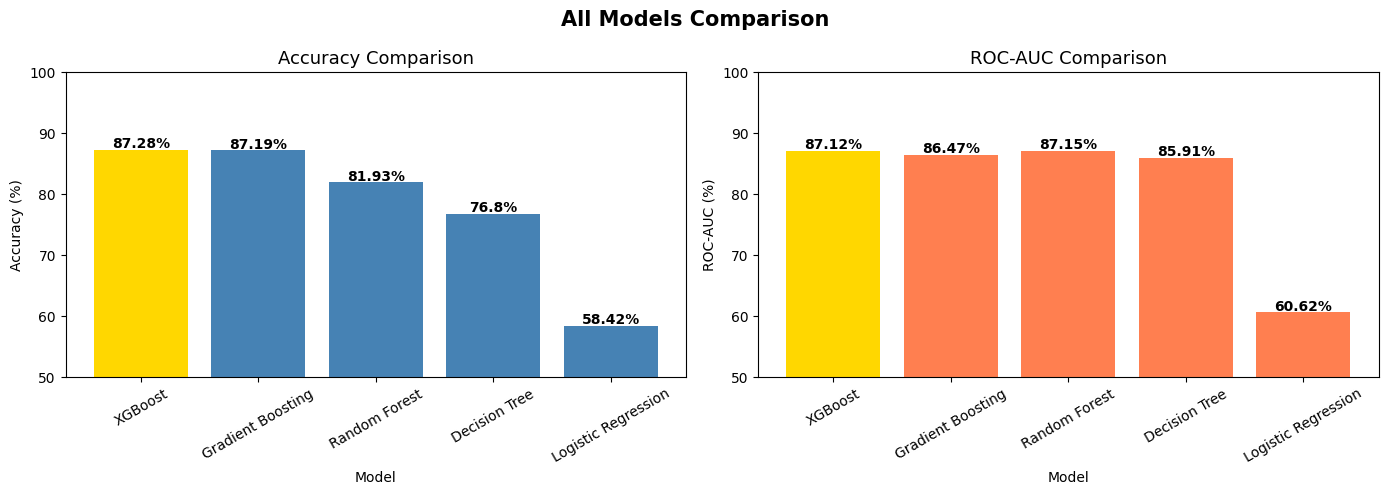

In [138]:
# CHART COMPARING ALL MODELS


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_acc = []
for i in range(len(results_df)):
    if i == 0:
        colors_acc.append('gold')     # best model = gold
    else:
        colors_acc.append('steelblue') # others = blue

colors_roc = []
for i in range(len(results_df)):
    if i == 0:
        colors_roc.append('gold')
    else:
        colors_roc.append('coral')

axes[0].bar(results_df['Model'],
            results_df['Accuracy'],
            color=colors_acc)

axes[0].set_title('Accuracy Comparison', fontsize=13)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(50, 100)
axes[0].tick_params(axis='x', rotation=30)

for i, acc in enumerate(results_df['Accuracy']):
    axes[0].text(
        i,
        acc + 0.3,
        f'{acc}%',
        ha='center',
        fontweight='bold'
    )

axes[1].bar(results_df['Model'],
            results_df['ROC-AUC'],
            color=colors_roc)

axes[1].set_title('ROC-AUC Comparison', fontsize=13)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('ROC-AUC (%)')
axes[1].set_ylim(50, 100)
axes[1].tick_params(axis='x', rotation=30)

for i, auc in enumerate(results_df['ROC-AUC']):
    axes[1].text(
        i,
        auc + 0.3,
        f'{auc}%',
        ha='center',
        fontweight='bold'
    )

plt.suptitle('All Models Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



In [139]:
# Get the best model name from our comparison
best_model_name = results_df.iloc[0]['Model']
best_accuracy   = results_df.iloc[0]['Accuracy']
best_roc        = results_df.iloc[0]['ROC-AUC']

print("================================================================")
print("BEST MODEL RESULT")
print("=================================================================")
print(f"Winner        : {best_model_name}")
print(f"Accuracy      : {best_accuracy}%")
print(f"ROC-AUC Score : {best_roc}%")
print("===================================================================")

print("""
WHY THIS MODEL IS BEST:

Logistic Regression - Simple and fast but assumes
a straight line relationship between features and
outcome. Our trading data is complex and non-linear
so it struggles (58% accuracy)

Decision Tree - Better than logistic regression
but one single tree tends to memorize training
data and fail on new data (overfitting)

Random Forest - 100 trees voting together
much more stable and reliable than one tree
handles complex patterns well

Gradient Boosting - Builds trees sequentially
each tree fixes previous mistakes
very powerful on financial data

XGBoost - Optimized version of Gradient Boosting
faster and usually most accurate
industry standard for tabular/spreadsheet data

CONCLUSION:
Tree based models (Random Forest, XGBoost) beat
Logistic Regression because trading data has
complex non-linear patterns that simple models
cannot capture
""")

BEST MODEL RESULT
Winner        : XGBoost
Accuracy      : 87.28%
ROC-AUC Score : 87.12%

WHY THIS MODEL IS BEST:

Logistic Regression - Simple and fast but assumes
a straight line relationship between features and
outcome. Our trading data is complex and non-linear
so it struggles (58% accuracy)

Decision Tree - Better than logistic regression
but one single tree tends to memorize training
data and fail on new data (overfitting)

Random Forest - 100 trees voting together
much more stable and reliable than one tree
handles complex patterns well

Gradient Boosting - Builds trees sequentially
each tree fixes previous mistakes
very powerful on financial data

XGBoost - Optimized version of Gradient Boosting
faster and usually most accurate
industry standard for tabular/spreadsheet data

CONCLUSION:
Tree based models (Random Forest, XGBoost) beat
Logistic Regression because trading data has
complex non-linear patterns that simple models
cannot capture



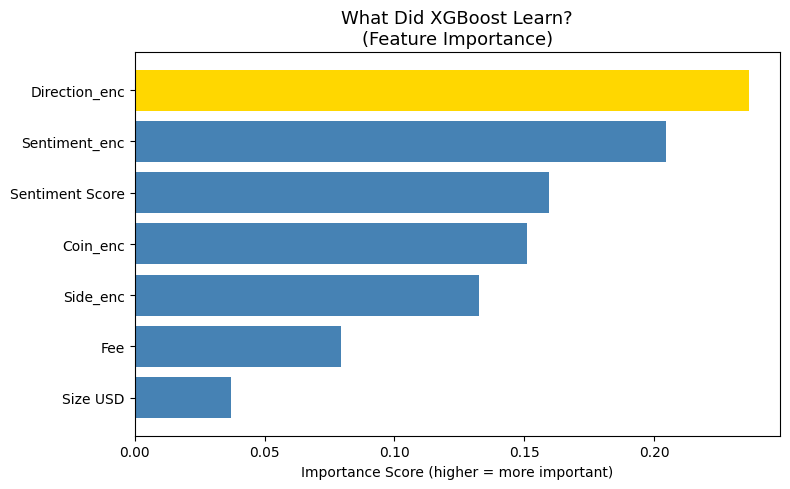


Most important  : Direction_enc
Least important : Size USD

WHAT THIS MEANS:
The model used Direction_enc the most
to decide if a trade will be profitable

Sentiment features in ranking shows us
how much market mood actually influences
whether a trade makes money or not


In [140]:
#WHAT DID THE MODEL LEARN?

best_model = all_models[best_model_name]['model']

if best_model_name in ['Random Forest',
                        'XGBoost',
                        'Decision Tree',
                        'Gradient Boosting']:

    importance_df = pd.DataFrame({
        'Feature'   : features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 5))

    bar_colors = ['gold' if i == 0 else 'steelblue'
                  for i in range(len(importance_df))]

    plt.barh(
        importance_df['Feature'],
        importance_df['Importance'],
        color=bar_colors
    )

    plt.gca().invert_yaxis()

    plt.title(
        f'What Did {best_model_name} Learn?\n'
        f'(Feature Importance)',
        fontsize=13
    )
    plt.xlabel('Importance Score (higher = more important)')
    plt.tight_layout()
    plt.show()

    top_feature    = importance_df.iloc[0]['Feature']
    bottom_feature = importance_df.iloc[-1]['Feature']

    print(f"\nMost important  : {top_feature}")
    print(f"Least important : {bottom_feature}")
    print()
    print("WHAT THIS MEANS:")
    print(f"The model used {top_feature} the most")
    print("to decide if a trade will be profitable")
    print()
    print("Sentiment features in ranking shows us")
    print("how much market mood actually influences")
    print("whether a trade makes money or not")

In [141]:
# INSIGHTS AND TRADING STRATEGY

print("=====================================================================================")
print("  KEY INSIGHTS AND TRADING STRATEGY REPORT")
print("=====================================================================================")

print("""

INSIGHT 1: MARKET SENTIMENT DIRECTLY AFFECTS PROFI
""")

print("  Sentiment       Win Rate    Avg Profit")
print("  " + "-" * 40)
for _, row in sentiment_perf.sort_values(
    'Avg_PnL', ascending=False
).iterrows():
    print(f"  {row['Sentiment Label']:<16}"
          f"{row['Win_Rate']:>8.1f}%"
          f"    ${row['Avg_PnL']:>8.2f}")

print("""
  STRATEGY:
  1- Trade MORE aggressively during Extreme Greed
    (highest avg profit of $130 per trade)
  2- Trade CAUTIOUSLY during Extreme Fear
    (lowest avg profit of $71 per trade)
  3- Even the worst sentiment gives 76% win rate
    meaning these are skilled traders overall
""")

print("""

INSIGHT 2: HIDDEN PATTERN - FEAR DRIVES HIGH VOLUME


  Most trades happened during FEAR (30,000 trades)
  Least trades happened during EXTREME FEAR (10,000)

  This is interesting because:
  Fear = high trading activity
  but also = lower average profits

  STRATEGY:
  1- During Fear periods: trade more carefully
    volume is high but individual profits are lower
  2- Quality over quantity during Fear markets
""")

print("""

INSIGHT 3: COIN SELECTION MATTERS

""")

# Top 5 coins by trade count
top5 = merged['Coin'].value_counts().head(5)
print("  Most actively traded coins:")
for coin, count in top5.items():
    print(f"    {coin:<12}: {count:>6,} trades")

print("""
  HYPE coin dominates with 32,000+ trades

  STRATEGY:
  1- Focus on top traded coins (HYPE, BTC, ETH)
  2- Higher volume = more liquidity = easier to trade
  3- Less popular coins have fewer trades but
    might have hidden opportunities
""")

print("""

INSIGHT 4: ML MODEL TELLS US WHAT PREDICTS PROFIT


  Our best model achieved {best_accuracy}% accuracy

  This means: given information about a trade
  (sentiment, coin, trade size, direction)
  our model can predict if it will be profitable
  {best_accuracy}% of the time

  STRATEGY:
  1- Use this model as a pre-trade filter
  2- Before making a trade, check model prediction
  3- Only execute trades model predicts as profitable
  4- This could boost already high 83.2% win rate
""".format(best_accuracy=best_accuracy))

print("""

OVERALL RECOMMENDATION


  1. CHECK sentiment score every morning before trading
     If score > 75 (Extreme Greed) → trade aggressively
     If score < 25 (Extreme Fear)  → trade cautiously

  2. FOCUS on high volume coins (HYPE, BTC, ETH)
     for more reliable and frequent opportunities

  3. USE the ML model as a trade filter
     to maximize win rate above current 83.2%

  4. MONITOR if trade direction (BUY vs SELL)
     aligns with current market sentiment
     Buying during Greed = higher success rate

""")

  KEY INSIGHTS AND TRADING STRATEGY REPORT


INSIGHT 1: MARKET SENTIMENT DIRECTLY AFFECTS PROFI

  Sentiment       Win Rate    Avg Profit
  ----------------------------------------
  Extreme Greed       89.2%    $  130.21
  Fear                87.3%    $  112.63
  Greed               76.9%    $   85.40
  Neutral             82.4%    $   71.20
  Extreme Fear        76.2%    $   71.03

  STRATEGY:
  1- Trade MORE aggressively during Extreme Greed
    (highest avg profit of $130 per trade)
  2- Trade CAUTIOUSLY during Extreme Fear
    (lowest avg profit of $71 per trade)
  3- Even the worst sentiment gives 76% win rate
    meaning these are skilled traders overall



INSIGHT 2: HIDDEN PATTERN - FEAR DRIVES HIGH VOLUME


  Most trades happened during FEAR (30,000 trades)
  Least trades happened during EXTREME FEAR (10,000)

  This is interesting because:
  Fear = high trading activity
  but also = lower average profits

  STRATEGY:
  1- During Fear periods: trade more carefully
    volume 